# Book Recommender System

A hybrid book recommendation engine combining **collaborative filtering** via matrix factorization with **semantic search** via sentence embeddings.

<!-- Table of Contents with All Section Levels -->
<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Table of Contents</h2>
    <p><a href="#section1" style="color: #2f1381; font-weight: bold; text-decoration: none;">1. Business Problem: Recommender System. ML Problem and Data Loading</a></p>
    <p><a href="#section2" style="color: #2f1381; font-weight: bold; text-decoration: none;">2. Basic Data Visualization</a></p>
    <p><a href="#section3" style="color: #2f1381; font-weight: bold; text-decoration: none;">3. Data Vectorization</a></p>
    <p><a href="#section4" style="color: #2f1381; font-weight: bold; text-decoration: none;">4. Model Definition</a></p>
    <p><a href="#section5" style="color: #2f1381; font-weight: bold; text-decoration: none;">5. Baseline Model</a></p>
    <p><a href="#section6" style="color: #2f1381; font-weight: bold; text-decoration: none;">6. Model Likelihood</a></p>
    <p><a href="#section7" style="color: #2f1381; font-weight: bold; text-decoration: none;">7. Loss Function</a></p>
    <p><a href="#section8" style="color: #2f1381; font-weight: bold; text-decoration: none;">8. Gradient Descent</a></p>
    <p><a href="#section9" style="color: #2f1381; font-weight: bold; text-decoration: none;">9. Overfitting</a></p>
    <p><a href="#section10" style="color: #2f1381; font-weight: bold; text-decoration: none;">10. Recommendations and Improvements</a></p>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from IPython.display import Markdown, display, HTML

%matplotlib inline

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">1. Business Problem: Recommender System</h2>
</div>

At Amazon, we understand the power of **personalized recommendations** in driving customer engagement and revenue growth. While our recommender systems are highly sophisticated and leverage cutting-edge machine learning techniques, the core principles can be distilled into fundamental mathematical and statistical concepts. The goal is to build a minimum viable **book recommender system** from the ground up. Through this hands-on experience, you'll gain insights into the iterative process of prototyping and refining recommendation algorithms, laying the foundation for more advanced exploration in this domain.

The objective is to build a __recommender system__ similar to those that you find used throughout any digital content provider which will attempt to predict user's preferences based upon past ratings. The technique we use is called a __model-based collaborative filtering__ where we use only a user's past behaviors (items previously purchased and ratings given to those items) to build a model to predict the missing data (ratings for items that the user may have an interest in).

<!-- Subsection Header -->
<div id="section1-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">1.1 Data Loading</h3>
</div>

You will be using a subset of Amazon reviews for the task. It is actually based on a public dataset collected by scraping all reviews prior to 2014, extracting userID, ASIN, and star rating. The dataset has evolved every since and can now be found as [Amazon Reviews dataset](https://amazon-reviews-2023.github.io/). This dataset itself would be very large and hard to train on owing to the fact there are many ASINs without only one or two reviews, and many users that only review one or two books. The subset we use is actually a very restricted subset known as the $40$-core. This is the collection of those ASINs and users such that every ASIN has at least 40 reviews and every user has reviewed at least 40 books. The ratings are on a scale from 1 to 5.

Let's load our datasets, ```training``` and ```test_features```. We build the recommender system using the ```training``` data and evaluate performance on the ```test_features```.

Notice that the ```test_features``` do not contain a column `Rating`, which is what you're expected to produce with your trained model. The ```test_features``` dataset is used to generate final predictions.

In [ ]:
# Import the datasets from the CSV files
training = pd.read_csv("training.csv")
test_features = pd.read_csv("test_features.csv")

# Display the head of the files
display(Markdown("### Sample training data"))
display(HTML(training.head(5).to_html()))

display(Markdown("### Sample test data"))
display(HTML(test_features.head(5).to_html()))

### Sample training data

,ID,User,ASIN,Rating
0,66799,A3NDST1X8JVAP7,1490471103,5
1,80385,A1E2T8OSEMVN3H,149473592X,5
2,80636,A3BR1CG9CRXB6Z,1494755610,5
3,45627,AGYHA346U3CNP,1477694919,2
4,78045,A2N0YZV2JT6O72,1493752650,5


### Sample test data

,ID,User,ASIN
0,84634,A1C7DFNSXTY09X,149617707X
1,55852,A13NJZ1M018A7C,1482594129
2,28875,A3RINEQ4GDTR55,144235948X
3,94134,A1W5758V90WQKZ,B008O0QUU2
4,31501,A243FA8XGHI63J,1455574880


The code below stores a list of the unique userIDs and ASINs, counts the number of such userIDs and ASINs, and then splits the ```training``` dataset into two sets: ```train``` (train set) and ```val``` (validation set). You can use the validation set to evaluate model performance during development.

In [3]:
# Count number of unique users and number of unique ASINs in our dataset
# Unique user who reviewed
unique_users = training["User"].unique().tolist()
# Unique books that were reviewed
unique_asins = training["ASIN"].unique().tolist()

# Sort data to avoid index matching errors later on
unique_users.sort()
unique_asins.sort()

n_users = len(unique_users)
n_asins = len(unique_asins)

display(Markdown("### Amount of data"))
display(Markdown(f"Number of Users: {n_users}"))
display(Markdown(f"Number of ASINs: {n_asins}"))

# Split into train and validation
train, val = train_test_split(training, random_state=42, stratify=training["ASIN"])
n_train = train.shape[0]
n_val = val.shape[0]

display(Markdown("### Size of data splits"))
display(Markdown(f"Shape of original Training Data: {training.shape}"))
display(Markdown(f"- of which shape of Train split: {train.shape}"))
display(Markdown(f"- and shape of Validation split: {val.shape}"))
display(Markdown(f"Shape of Test Features Data: {test_features.shape}"))

### Amount of data

Number of Users: 1490

Number of ASINs: 1186

### Size of data splits

Shape of original Training Data: (81472, 4)

- of which shape of Train split: (61104, 4)

- and shape of Validation split: (20368, 4)

Shape of Test Features Data: (27158, 3)

<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">2. Basic Data Visualization</h2>
</div>

Let's dig in and start to do some data visualization. When working with real-world data, it is always important to try to understand what bizarre little issues it has. We've removed many of these for you, but all the same we should do at least a tiny exercise in data visualization so we can see some features of our data.

In a real world setting, data collected from feedbacks like user ratings can be very sparse and data points are mostly collected from very popular items (books) and highly engaged users. Large amount of less known items (books) don't have ratings at all. Let's see some plots on the distribution of books ratings frequency, to have a __better idea of the data we have__, and ponder whether is enough (and good enough) for a recommender model.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Data visualization</h4>
        <p>Use <a href="https://matplotlib.org/">matplotlib</a> to produce the following two plots:</p>
        <ul>
            <li>the <a href="https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html">histogram</a> of the number of reviews given by the users</li>
            <li>a <a href="https://matplotlib.org/api/_as_gen/matplotlib.pyplot.scatter.html">scatter plot</a> of the average rating of an ASIN versus the number of ratings received by the ASIN.</li>
        </ul>
        <p>It is good practice to not touch the testing data during model development, so make these plots only on the train data.</p>
    </div>
</div>

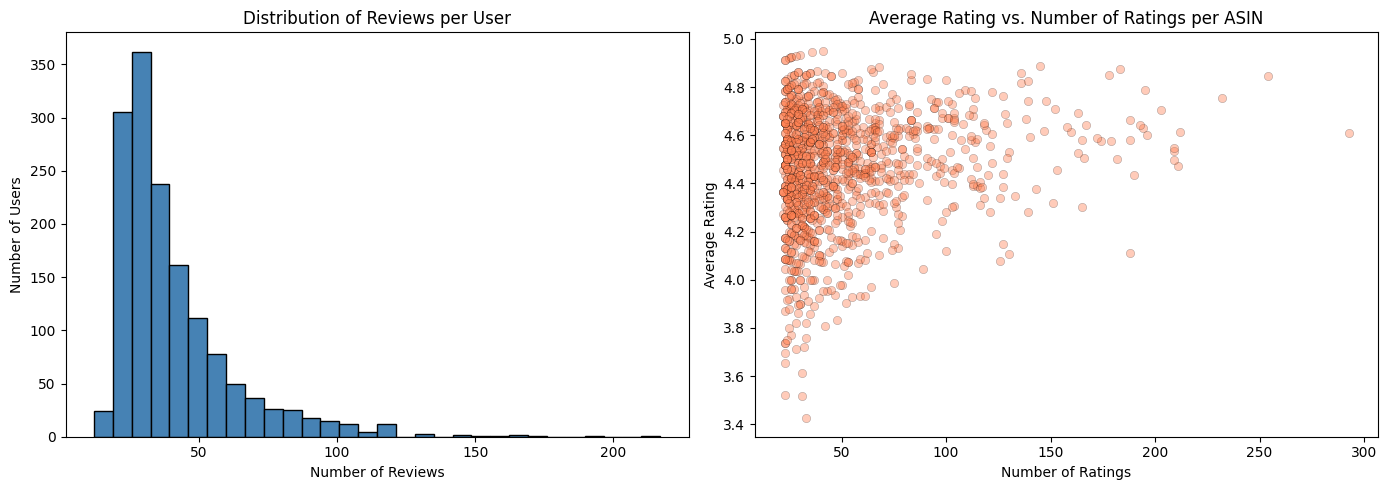

Users with fewest reviews: 12
Users with most reviews: 217
Median reviews per user: 34


In [4]:
# Histogram of number of reviews given by users
user_review_counts = train.groupby("User")["Rating"].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_review_counts, bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Number of Reviews")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Distribution of Reviews per User")

# Scatter plot of average rating vs number of ratings per ASIN
asin_stats = train.groupby("ASIN")["Rating"].agg(["mean", "count"])

axes[1].scatter(asin_stats["count"], asin_stats["mean"], alpha=0.4, color='coral', edgecolors='k', linewidths=0.3)
axes[1].set_xlabel("Number of Ratings")
axes[1].set_ylabel("Average Rating")
axes[1].set_title("Average Rating vs. Number of Ratings per ASIN")

plt.tight_layout()
plt.show()

print(f"Users with fewest reviews: {user_review_counts.min()}")
print(f"Users with most reviews: {user_review_counts.max()}")
print(f"Median reviews per user: {user_review_counts.median():.0f}")



<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> It is helpful to use like <code>.groupby([feature1][feature2].count()</code> or <code>.groupby([feature1][feature2].mean()</code> to prepare the data for the desired plots.</p>
</div>

<!-- Section Header -->
<div id="section3" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">3. Data Vectorization</h2>
</div>

Now that we agree that we have enough data for a recommender system, we can start designing a machine learning model to solve the problem. But if you go up and look again at the samples from the datasets, you'll notice that the data is not a vector or matrix. Various columns are strings rather than numbers, and even if we solved that (say by creating a unique ID number for every ASIN and user) it would still be in a very strange format. __Deciding how to represent your data is a major first step in any ML problem.__

First, you need to transform the dataframe of ratings into a proper format that can be consumed by a machine learning model, with a recommender system in mind. In fact, __you want the data to be in an $n\times m$ matrix format__, where $n$ is the number of users and $m$ is the number of ASINs.

We can think of the data as a score matrix $S = \left(s_{i,j}\right)$ which is a $n\times m$ matrix where
$$
s_{i,j} = \begin{cases}
s & \text{if the rating by user $i$ to ASIN $j$ was $s$ stars,}\\
0 & \text{otherwise,}
\end{cases}
$$
where $n$ is the number of users and $m$ is the number of ASINs.

As you might notice, the data is extremely sparse, meaning that the $S$ matrix contains many zero elements. That makes sense, after examining the plots from Question 1: each user only rated a small number of ASINs. It will be useful to define another matrix, the matrix of which ASINs were rated.

Let $R = \left(r_{i,j}\right)$ be the matrix where
$$
r_{i,j} = \begin{cases}
1 & \text{if user $i$ rated ASIN $j$,}\\
0 & \text{otherwise.}
\end{cases}
$$
This matrix will allow you to mask off which entries were observed or not.

These two matrices, $S$ and $R$, will form the core of the work for this project, so it is a good idea to define them and create them now.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Data vectorization</h4>
        <p>Translate the Pandas DataFrames that contain the train and validation data into two numpy matrices each: the score matrix <code>S</code> and the mask matrix <code>R</code>. This will leave you with four matrices:</p>
        <ul>
            <li><code>R_train</code>,</li>
            <li><code>S_train</code>,</li>
            <li><code>R_val</code>, and</li>
            <li><code>S_val</code>.</li>
        </ul>
        <p>Print all four matrices and examine their elements. These are sparse matrices, so many of them should be zero.</p>
    </div>
</div>

In [5]:
def create_matrices(df, unique_users, unique_asins):
    pivot = df.pivot_table(index="User", columns="ASIN", values="Rating", fill_value=0)
    pivot = pivot.reindex(index=unique_users, columns=unique_asins, fill_value=0)
    S = pivot.values.astype(float)
    R = (S != 0).astype(float)
    return S, R

S_train, R_train = create_matrices(train, unique_users, unique_asins)
S_val, R_val = create_matrices(val, unique_users, unique_asins)

print("Matrix shapes:")
print(f"  R_train: {R_train.shape}, S_train: {S_train.shape}")
print(f"  R_val:   {R_val.shape},   S_val:   {S_val.shape}")

print(f"\nSparsity of S_train: {1 - R_train.mean():.2%} zeros")
print(f"Sparsity of S_val:   {1 - R_val.mean():.2%} zeros")

print("\nSample of R_train (5x5):\n", R_train[:5, :5])
print("\nSample of S_train (5x5):\n", S_train[:5, :5])
print("\nSample of R_val (5x5):\n", R_val[:5, :5])
print("\nSample of S_val (5x5):\n", S_val[:5, :5])



Matrix shapes:
  R_train: (1490, 1186), S_train: (1490, 1186)
  R_val:   (1490, 1186),   S_val:   (1490, 1186)

Sparsity of S_train: 96.54% zeros
Sparsity of S_val:   98.85% zeros

Sample of R_train (5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Sample of S_train (5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Sample of R_val (5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Sample of S_val (5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> It is helpful to know that, other than defining the matrices with for loops or list comprehensions, you can also use <code>pd.pivot_table</code> to pivot the dataframes to the desired format with users as rows and ASINs as columns. This second approach is much more performant than the first one.</p>
</div>

<!-- Section Header -->
<div id="section4" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">4. Model Definition</h2>
</div>

To better understand how to build a recommender system by [collaborative filtering](https://en.wikipedia.org/wiki/Collaborative_filtering#), it helps to print and examine the ```S_train``` matrix. You'll notice the majority of zero entries. In order to define the model, you need to have some way of making predictions for the unfilled entries -- that's ultimately the recommender system.

Your goal with this project is to construct a prediction matrix $P = (p_{i,j})$ that fills in all the missing scores where $r_{i,j} = 0$. If you assumed nothing about how the matrix $P$ is constructed, there would have no basis to build a prediction. You will need to assume that $P$ is generated from some process that has more structure than just an arbitrary matrix.

As already mentioned, the $S$ matrices have many zeros. Moreover, they are very large, 1490 by 1186 (and they could be even bigger in other practical scenarios!). Remember all the computational impediments related to storing, working, and manipulating large matrices, even on current high-dimensionality friendly ML frameworks. __Reducing dimensions__ can improve the performance of the algorithm in terms of both storage and time. Matrix factorization is a simple way to build larger matrices from smaller ones.

You also need to find out how some users preferences of some ASINs might impact other unexplored users-ASINs ratings. Somehow you want to connect users-ASINs-ratings in a meaningful way to extract __underlying relationships__ that might exist between users and ASINs to explain their corresponding ratings, and leverage these __latent relationships__ to predict other users-ASINs interactions. This could be modeled linearly by factorizing the initial matrix in terms of the product of two matrices.

<!-- Subsection Header -->
<div id="section4-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">4.1 Matrix Factorization</h3>
</div>

The prediction matrix will be the __product of two other matrices__. You will decompose the users-ASINs interactions matrix into the product of two lower-dimensionality rectangular matrices. These matrices represent the users and ASINs individually.
* The first matrix $A$ can be seen as the _users matrix_, where rows represent the users, and columns tell us about some of users' affinities for ASINs -- let's call it the *affinities* matrix $A$.
* The second matrix $F$ can be seen as the _ASINs matrix_, where rows tell us about the features ASINs have to offer to users, and columns represent the ASINs -- let's call it the *features* matrix $F$.

The columns in the users *affinities* matrix $A$ and the rows in the ASINs *features* matrix $F$ are called **latent factors** and are an indication of hidden characteristics about the users or the ASINs, patterns in the data that could lead to more personalized recommendations. The number of such latent factors can be anything from one to hundreds. This number is one of the things that can be optimized during the training of the model.

Mathematically, the idea is the following:
* To each ASIN $j$ we will associate $k$ features $(f_{\ell,j})_{\ell = 1}^k$. These features can be thought of as simple descriptors of the book, like for instance amount of action or romance, although we don't need to know what they are when we propose the model (i.e. this is not a _content-based_ recommender system.
* To each user $i$ we will associate $k$ affinities $(a_{i,\ell})_{\ell=1}^k$. The affinities can be thought of as providing how much a person likes or dislikes a feature; so perhaps $+1$ for action, since they like action, and $-0.5$ for romance. Again, we don't need to define what these affinities are when we propose the model. These latent factors will be learned from the training data.

__The rating that a user will assign to a ASIN will be taken as a sum over all the features of their affinities for that feature times that ASIN's features.__

Regarding terminology, in the world of ML, a *parameter* is a number that needs to be fixed in order to specify a model completely. For instance, in this case every affinity and every feature must be specified for our model to be able to make predictions. For instance, if every user has two features, and every ASIN has two features, the total number of parameters is:
$$
\#\text{Parameters} = 2\cdot\#\text{User} + 2 \cdot\#\text{ASIN}.
$$

As a general rule of thumb, the more parameters you have, the more data you need to fit your model. an old statistics rule stated that you need about 10 data points for each parameter. There are exceptions to this rule (particularly in deep learning), but it is always a good idea to keep the number of parameters always in mind.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Model definition</h4>
        <p>Express the model described above mathematically in matrix notation as a product of the matrices of features and affinities.</p>
        <ul>
            <li>What are the dimensions of the matrices involved?</li>
            <li>How many parameters are there in this model?</li>
            <li>How does the number of parameters compare to the number of entries of $P$?</li>
        </ul>
        <p>Complete this question in abstract matrices shapes (in terms of $m,n,$ and $k$), and then say what this means for our dataset, in particular with $k=2$, in comparison to the total number of entries in $P$.</p>
    </div>
</div>

---

**Matrix Notation:**

The prediction matrix is P = A · F where:
- A is the affinities matrix of shape n × k
- F is the features matrix of shape k × m
- P = AF has shape n × m

Number of parameters = n·k + k·m = k(n + m)

For k=2, n=1490, m=1186:
  Parameters = 2 × (1490 + 1186) = 5,352
  Entries in P = 1490 × 1186 = 1,767,140

The model has ~330× fewer parameters than entries in P.
This forces the model to find real structure rather than memorize ratings.

---

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> It is helpful to remember the formula for the matrix multiplication.</p>
</div>

<!-- Section Header -->
<div id="section5" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">5. Baseline Model</h2>
</div>

If you answered the question above, you realized that the total number of parameters of the proposed model is vastly smaller than the total number of entries in the matrix $P$. This is a key aspect: since we need to find the values for a comparatively small number of parameters to specify all of $P$, the model will be forced to find structure in the observations rather than to memorize scores. This helps generalize to unseen pairs of user-ASINs.

Let's consider the simplest example of this type of models. __Set $\mathbf{k=1}$__. Pick the single feature as the average star rating an ASIN received, and assume every user has affinity of $+1$ for that feature. This is a __rank-1 approximation__. When you do the product of $P=AF$, note that this means that it predicts that every single user gives the same rating to the ASIN, and that rating is the average value that other users gave to that ASIN. Throughout this notebook, we will refer to this as the __baseline model__. This gives a simple benchmark against which to measure progress.

In terms of evaluation metrics, it is reasonable to measure the quality of the predictions by computing the average squared difference between the predictions and the true values in the *test* set, where the test set can be any set we would like to test our model against (the train or the validation set, for example):

$$
{\frac{1}{\#\text{Test data points}}\sum_{\text{Test data}}(\text{prediction} - \text{true test observation})^2}
$$

This is called the mean squared error (or MSE for short). MSE is expressed in units that are difficult to interpret, so the Root Mean Square (RMS) can be used instead. The RMS error can be thought of in terms of how far the predictions are off on average and is obtained by taking the square root of the MSE:

$$
\sqrt{{\frac{1}{\#\text{Test data points}}\sum_{\text{Test data}}(\text{prediction} - \text{true test observation})^2}}.
$$

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Baseline model</h4>
        <p>Write code to compute the vector of average ASIN scores from the training set as our single feature. Construct a vector of all ones for your vector of affinities, and then use these two vectors to create a (baseline) matrix of predictions $P$.</p>
        <ul>
            <li>Print the matrix $P$ and examine its elements. How does it compare to the validation matrix $S$?</li>
            <li>Compute the MSE and the RMS on the validation set. How far off are we on average if we use this simple method for prediction?</li>
        </ul>
        <p><b>The csv file needs two columns: the ID of the User-ASIN interaction (first column of <code>test_features</code>) and a <code>Rating</code> column with the predicted rating for each pair.</b></p>
    </div>
</div>

In [6]:
# Compute average rating per ASIN from training data only
asin_avg = train.groupby("ASIN")["Rating"].mean()
global_avg = train["Rating"].mean()

# Feature vector f: average rating for each ASIN
f = np.array([asin_avg.get(asin, global_avg) for asin in unique_asins])

# Affinity vector a: all ones
a = np.ones(n_users)

# Baseline prediction matrix
P_baseline = np.outer(a, f)  # shape: n_users x n_asins

print("P_baseline shape:", P_baseline.shape)
print("Sample predictions (first 3 users, first 3 ASINs):\n", P_baseline[:3, :3])

# Evaluate on validation set
N_val = int(R_val.sum())
mse_val = np.sum(R_val * (S_val - P_baseline) ** 2) / N_val
rms_val = np.sqrt(mse_val)

print(f"\nBaseline Validation MSE: {mse_val:.4f}")
print(f"Baseline Validation RMS: {rms_val:.4f}  (predictions off by ~{rms_val:.2f} stars on average)")

# Create submission CSV
baseline_predictions = []
for _, row in test_features.iterrows():
    user_idx = unique_users.index(row["User"])
    asin_idx = unique_asins.index(row["ASIN"])
    baseline_predictions.append(P_baseline[user_idx, asin_idx])

pd.DataFrame({"ID": test_features["ID"], "Rating": baseline_predictions}).to_csv(
    "baseline_submission.csv", index=False
)
print("\nbaseline_submission.csv created.")



P_baseline shape: (1490, 1186)
Sample predictions (first 3 users, first 3 ASINs):
 [[4.33333333 4.58       4.53846154]
 [4.33333333 4.58       4.53846154]
 [4.33333333 4.58       4.53846154]]

Baseline Validation MSE: 0.5920
Baseline Validation RMS: 0.7694  (predictions off by ~0.77 stars on average)

baseline_submission.csv created.


<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> To create a vector of ones, use <a href="https://numpy.org/doc/stable/reference/generated/numpy.ones.html"><code>np.ones</code></a>.</p>
    <p style="color: #16A085; margin: 0;">For ease of implementation, note that the RMS is the same as
$$
RMS = \frac{1}{\sqrt{\text{Test data points}}}\|R\circ(S-P)\|_2
$$
where we use $R$ to mask off only the observed test entries, and the fact that the $L_2$ norm is the square root of the sum of the squares of entries. Using matrix products (implemented with <code>np.dot(A, B)</code>), the Hadamard product (implemented with <code>np.multiply(A, B)</code> or <code>A*B</code>), and <code>np.linalg.norm</code> for the $L_2$ norm, computing the RMS can be done in one line of code.</p>
</div>

<!-- Section Header -->
<div id="section6" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">6. Model Likelihood</h2>
</div>

### Propose a model to capture the underlying relationship in the dataset

This section is entirely theoretical and will contain no code. The proposed model for the recommender system is such that predicted ratings are obtained as $P = AF$. Unless the universe follows our model exactly, meaning that there are truly just $k$ numbers that determine how much a person likes a book and the person assigns that score every single time without fail, it won't be true that $S = AF$. Instead, $S$ will look like $P=AF$ plus some __independent random noise__, where that random noise is designed to capture all the inaccuracies in the model, for instance there can be random fluctuation in the rating given depending on things unrelated to the book at all.

The way to model this is to say that
$$
S\sim P + \mathcal{N}(0,\sigma^2),
$$
where the noise is modeled as independent additive Gaussian noise. The way to read this is that every observed rating $s_{i,j}$ is distributed as a prediction $p_{i,j}$ plus independent, zero-mean Gaussian noise of unknown variance for every observation. Since adding a constant to a Gaussian just shifts the mean, we could also say that
$$
s_{i,j}\sim\mathcal{N}(p_{i,j},\sigma^2).
$$
The scale of the noise, $\sigma^2$, is now an additional parameter of the model.

### Compute the likelihood that this model generates the data

For many __independent observations__, as assumed for the ratings, each with its own Gaussian probability densities as proposed above, the probability to observe all datapoints (ratings) at the same time is given by the product of the individual probabilities. The probability or probability density of obtaining a particular set of data is often called the __likelihood__.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Model likelihood</h4>
        <p>Let $N$ be the total number of observed ratings (of the training dataset). For the proposed model, explain why the likelihood is:</p>
        <p>$$ \left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^N e^{\displaystyle{-\frac{1}{2\sigma^2}\sum_{N}(s_{i,j} - p_{i,j})^2}}. $$</p>
        <p>Write your derivation below.</p>
    </div>
</div>

---

Each observed rating s_{i,j} ~ N(p_{i,j}, σ²), so its density is:

  p(s_{i,j}) = (1/√(2πσ²)) · exp(-(s_{i,j} - p_{i,j})² / 2σ²)

Since all N ratings are independent, the joint likelihood is the product:

  L = ∏_N (1/√(2πσ²)) · exp(-(s_{i,j} - p_{i,j})² / 2σ²)

The constant (1/√(2πσ²)) appears N times → (1/√(2πσ²))^N

Using e^a · e^b = e^(a+b), the product of exponentials becomes a single exponential:

  L = (1/√(2πσ²))^N · exp(-1/(2σ²) · Σ_N (s_{i,j} - p_{i,j})²)

---

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> For the derivation you need to use a fundamental property of the exponential function: $$\displaystyle{e^a e^b = e^{a+b}}.$$</p>
</div>

<!-- Section Header -->
<div id="section7" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">7. Loss Function</h2>
</div>

### Compute the negative log-likelihood (loss function)

The maximum likelihood estimation process is based on finding out what values of the model parameters make the data most likely, in the sense of occurring with the highest probability. Notice that many of the terms above in the likelihood we computed are unrelated to the dataset, such as the factor in front of the exponential. To find the choice of predictions $p_{i,j}$ that maximizes the probability, or the likelihood rather, one can ignore most things in the likelihood and focus on the piece that contains the observations $p_{i,j}$.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Loss function</h4>
        <p>Explain that discarding all terms that do not involve the data, the negative $\log$-likelihood (the <b>loss function</b>) is essentially:</p>
        <p>$$\sum_{N}(s_{i,j} - p_{i,j})^2.$$</p>
        <p>Explain why minimizing the loss function is the same as minimizing the MSE error. This indicates that minimizing the intuitively reasonable MSE error is the same thing as maximizing the probability of the data.</p>
    </div>
</div>

---

Taking the negative log-likelihood:

  -log L = N·log(√(2πσ²)) + (1/2σ²) · Σ_N (s_{i,j} - p_{i,j})²

The first term is constant w.r.t. A and F — discarding it gives the loss:

  L(A,F) ∝ Σ_N (s_{i,j} - p_{i,j})²

MSE = (1/N) · Σ_N (s_{i,j} - p_{i,j})²

This is just the loss divided by the positive constant N, so the same (A,F)
minimizes both. Minimizing MSE = maximizing the likelihood under Gaussian noise.

---

<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> It helps to remember some of the properties of the logarithm: $$\log(ab) = \log(a) + \log(b),$$ $$\log(a^N) = N \log(a),$$ $$\log(e) = 1.$$ However, the question can be answered even without using negative log, just by noticing that $e^{-x}$ is a decreasing function.</p>
</div>

<!-- Section Header -->
<div id="section8" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">8. Gradient Descent</h2>
</div>

### Find the model that minimizes the loss function

You will use __gradient descent__ to minimize the loss funtion iteratively, and consequently __learn the model from the train data__.

While the section above mentions minimizing the RMS as a more interpretable metric, one can instead optimize the MSE with the same results, which has the advantage of avoiding the square root. This freedom is useful: you can think about RMS if to interpret the results, and use instead the MSE to computationally optimize the model.

Let's recap: it is reasonable to model the matrix of predictions as the product $AF$, since it corresponded to the idea that users have various preferences for various features of each ASIN. If this was not an ML problem, one could assign to every ASIN a list of features by hand (perhaps using Mechanical Turk), and then hand-code rules like, "if a person has assigned 5 stars to at least 10 sci-fi books, then they have affinity $+1$ for sci-fi books." This would likely work, but there is a lot of trial and error, and human labor.

The ML solution is to essentially work this problem backwards. We suppose that such features exist, we define a way to evaluate how well a collection of features and affinities works to describe the scores we observe, and then we try to automatically find the best possible set of features and affinities to explain the data we've seen. Thus, our goal is to find the best possible values for $A$ and $F$ in the sense that they minimize the MSE.

<!-- Subsection Header -->
<div id="section8-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">8.1 Implementing Gradient Descent with autograd</h3>
</div>

Let's now dive in to the implementation of gradient descent for this problem. The mean squared error loss function can be written as

$$
L(A,F) = \frac{1}{N}\|R\circ(S-AF)\|_2^2,
$$

where the variables have the following meanings:
* $N$ is the number of data points in the dataset used to define $R$ or $S$. It could be either the training or testing data.
* $k$, while not contained in the above formula, is the number of features describing each ASIN and affinities describing each user. This is a hyperparameter that is set when one creates the matrices $A$ and $F$.
* $R$ is the matrix that masks off those entries for which a rating is available.
* $S$ is the matrix of observed ratings.
* $A$ are the affinities of the users for various features.
* $F$ are the values of those features for all the ASINs.
* $AF$ is the matrix product that contains the predictions of ratings for every pair of user and ASIN.

To perform our gradient descent, you need to compute the gradient of the mean square errors loss function with respect to the parameters of the model: the entries of $A$ and $F$. While this loss function is still simple enough that one could work with this mathematically to find its derivatives, here you will approach this with automatic differentiation and autograd.

In order to implement gradient descent to solve the problem you need to define a few things:
* How to initialize $A$ and $F$?
* What to take for the number of features/affinities ($k$)?
* What to use as learning rate?
* When to stop the optimization?

To find the best values, you would want to do some *hyperparameter tuning*, meaning an optimization of the choices made before running the optimization algorithm. Here are some choices that work well, but feel free to experiment and test further:
* Initialize $A$ and $F$ with values from a Gaussian distribution of mean 0 and std 1.
* Take the number of features $k=2$.
* Take the learning rate to be $25.0$
* Stop after $500$ steps.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Gradient descent implementation</h4>
        <p>Implement the gradient descent algorithm and train the recommender system. To monitor learning of your model, plot the MSE error on both the train and validation data as a function of the number of iterations.</p>
        <p>How does the final validation loss compare with the value that you obtained using the baseline model from Question 4?.</p>
        <p><b>The csv file needs two columns: the ID of the User-ASIN interaction (first column of <code>test_features</code>) and a <code>Rating</code> column with the predicted rating for each pair.</b></p>
    </div>
</div>

Step  100/500  Train MSE: 0.4099  Val MSE: 0.4880
Step  200/500  Train MSE: 0.3876  Val MSE: 0.4595
Step  300/500  Train MSE: 0.3800  Val MSE: 0.4559
Step  400/500  Train MSE: 0.3743  Val MSE: 0.4569
Step  500/500  Train MSE: 0.3695  Val MSE: 0.4592

Training time: 6.1s
Final Train MSE: 0.3695
Final Val   MSE: 0.4592  (Baseline was 0.5920)


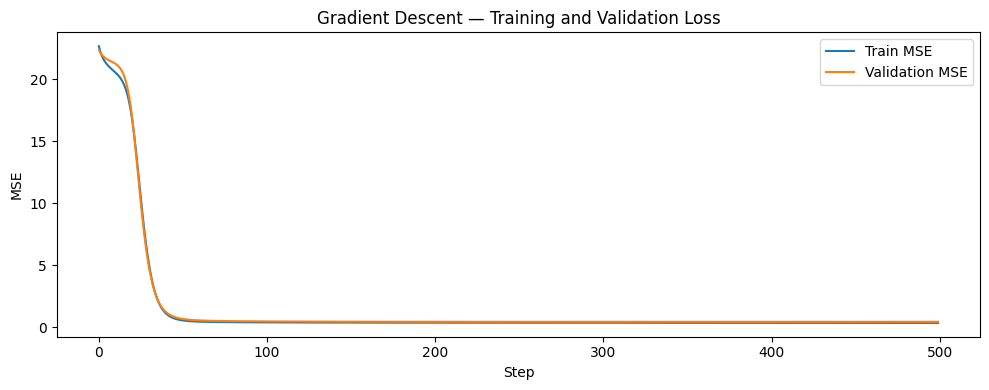

gd_submission.csv created.


In [7]:
# Hyperparameters
k = 2
lr = 25.0
n_steps = 500

# Convert to float32 tensors
S_train_t = torch.tensor(S_train, dtype=torch.float32)
R_train_t = torch.tensor(R_train, dtype=torch.float32)
S_val_t   = torch.tensor(S_val,   dtype=torch.float32)
R_val_t   = torch.tensor(R_val,   dtype=torch.float32)

N_train_count = R_train_t.sum().item()
N_val_count   = R_val_t.sum().item()

# Initialize A and F from N(0, 1)
torch.manual_seed(42)
A = torch.randn(n_users, k, requires_grad=True)
F = torch.randn(k, n_asins, requires_grad=True)

train_losses = []
val_losses   = []

start = time.time()
for step in range(n_steps):
    P = A @ F
    train_loss = torch.sum(R_train_t * (S_train_t - P) ** 2) / N_train_count
    train_loss.backward()

    with torch.no_grad():
        A -= lr * A.grad
        F -= lr * F.grad
        A.grad.zero_()
        F.grad.zero_()

    with torch.no_grad():
        val_loss = torch.sum(R_val_t * (S_val_t - A @ F) ** 2) / N_val_count

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (step + 1) % 100 == 0:
        print(f"Step {step+1:4d}/{n_steps}  Train MSE: {train_loss.item():.4f}  Val MSE: {val_loss.item():.4f}")

print(f"\nTraining time: {time.time()-start:.1f}s")
print(f"Final Train MSE: {train_losses[-1]:.4f}")
print(f"Final Val   MSE: {val_losses[-1]:.4f}  (Baseline was {mse_val:.4f})")

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses,   label="Validation MSE")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title("Gradient Descent — Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Generate test predictions
P_gd = (A @ F).detach()
gd_predictions = []
for _, row in test_features.iterrows():
    user_idx = unique_users.index(row["User"])
    asin_idx = unique_asins.index(row["ASIN"])
    gd_predictions.append(P_gd[user_idx, asin_idx].item())

pd.DataFrame({"ID": test_features["ID"], "Rating": gd_predictions}).to_csv(
    "gd_submission.csv", index=False
)
print("gd_submission.csv created.")



<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> Remember that to use <code>torch.autograd</code> you need to transform your data into <code>torch.tensor</code> type with <code>requires_grad=True</code>.</p>
</div>

<!-- Section Header -->
<div id="section9" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">9. Overfitting</h2>
</div>

If all goes well over the training period, the training and validation losses are both decreasing over the entire run, and probably finally end up somewhere lower than the baseline values, so there is an improvement in recommendation quality over the baseline model. However, in many ocassions, the training comes to a point when further iterations lead to a decrease of the training loss while the validation loss starts increasing.

This is one of the most pervasive issues in machine learning: __the phenomenon of overfitting__. It refers to a model memorizing random fluctuations rather than true patterns. The model's ability to predict on unseen data becomes *worse* after continued training, even though the models ability to explain training data becomes better. The idea is that in the beginning, the model is learning real and generalizable patterns, however, as it keeps learning for longer, it starts picking up on things which it *thinks* are real patterns, but are instead just random fluctuations. The model is *memorizing* the training data, instead of learning to generalize.

Let's examine at little bit closer the training and validation losses in the trained model, to make sure they are indeed both decreasing over the entire run as expected.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Overfitting</h4>
        <p>Plot the training and validation losses from the previous question, but now only do so for steps $100$ through $500$. There were many large gains in the early steps of gradient descent that make the overfitting harder to see which should now become clearer.</p>
        <p>A useful technique to prevent overfitting is called *early stopping*, where you simply stop training your model at the point at which the validation losses were best. What was the minimum value of the validation loss you obtained?</p>
        <p>You can now run a training loop and stop at the point before the validation loss starts increasing.</p>
    </div>
</div>

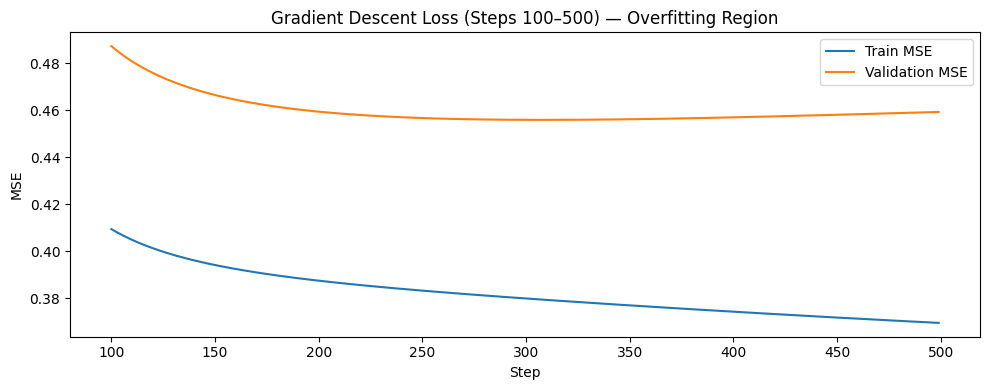

Minimum Validation MSE: 0.4559 at step 309
Early stopping triggered at step 329.
Best Validation MSE with early stopping: 0.4559
early_stopping_submission.csv created.


In [8]:
# Plot losses from step 100 to 500 to make overfitting visible
plt.figure(figsize=(10, 4))
plt.plot(range(100, n_steps), train_losses[100:], label="Train MSE")
plt.plot(range(100, n_steps), val_losses[100:],   label="Validation MSE")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title("Gradient Descent Loss (Steps 100–500) — Overfitting Region")
plt.legend()
plt.tight_layout()
plt.show()

best_step = int(np.argmin(val_losses))
print(f"Minimum Validation MSE: {val_losses[best_step]:.4f} at step {best_step + 1}")

# Retrain with early stopping
torch.manual_seed(42)
A_es = torch.randn(n_users, k, requires_grad=True)
F_es = torch.randn(k, n_asins, requires_grad=True)

best_val_loss = float("inf")
best_A_es, best_F_es = None, None
patience        = 20
patience_counter = 0

es_train_losses, es_val_losses = [], []

for step in range(n_steps):
    P_es = A_es @ F_es
    train_loss = torch.sum(R_train_t * (S_train_t - P_es) ** 2) / N_train_count
    train_loss.backward()

    with torch.no_grad():
        A_es -= lr * A_es.grad
        F_es -= lr * F_es.grad
        A_es.grad.zero_()
        F_es.grad.zero_()

    with torch.no_grad():
        val_loss = torch.sum(R_val_t * (S_val_t - A_es @ F_es) ** 2) / N_val_count

    es_train_losses.append(train_loss.item())
    es_val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_A_es = A_es.detach().clone()
        best_F_es = F_es.detach().clone()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at step {step + 1}.")
            break

print(f"Best Validation MSE with early stopping: {best_val_loss:.4f}")

# Submission
P_es_best = best_A_es @ best_F_es
es_predictions = []
for _, row in test_features.iterrows():
    user_idx = unique_users.index(row["User"])
    asin_idx = unique_asins.index(row["ASIN"])
    es_predictions.append(P_es_best[user_idx, asin_idx].item())

pd.DataFrame({"ID": test_features["ID"], "Rating": es_predictions}).to_csv(
    "early_stopping_submission.csv", index=False
)
print("early_stopping_submission.csv created.")



<!-- Tip Box -->
<div style="background-color: #E8F8F5; border-left: 5px solid #1ABC9C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #16A085; margin: 0;"><strong>Tip:</strong> To implement early stopping, you can create a variable to store the best (lowest) validation loss that is seen during the training. When a new validation loss happens to be larger than the best, indicating the start of the overfitting, you can decide to stop the training.</p>
    <p style="color: #16A085; margin: 0;">Often, the first sign of no further improvement may not be the best time to stop the training though. The model might be in a plateau or even get slightly worse before getting much better. You can account for this by adding a delay to the early stopping. You can set a "patience" argument and stop the training only when the validation loss fails to improve during a certain number of epochs given by the "patience".</p>
</div>

<!-- Section Header -->
<div id="section10" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">10. Recommendations and Improvements</h2>
</div>

By now you have gained expertise in building a baseline model for the recommender system, plus a trained model with gradient descent and optional early stopping.

Let's take a look at the model that you have built. Your last $P$ matrix from the gradient descent algorithm now contains entries for all pairs of users and items. Those entries of the $S$ matrix are now filled in with what are in fact recommendations for those users that have not yet rated those ASINs.

In [9]:
# Use the gradient descent prediction matrix (A @ F from section 8)
P = (A @ F).detach()

# P contains predicted ratings for all users and ASINs
dfP = pd.DataFrame(P.numpy(), columns=unique_asins)
dfP.index = unique_users

dfP.head()

,0007442920,0062267159,0062267175,006226768X,0062267728,0062267744,0062267884,0062267906,0062273248,0062273264,...,B00KPIPQJ2,B00KTI9R6Q,B00KUEGX16,B00KV13TKG,B00L1MSEZO,B00L9HIR4E,B00LD6IYUS,B00LD8K0KI,B00LDD8NDO,B00LLWDUDK
A01911642JTFI4ONWRUNF,5.332297,4.596529,3.502713,2.760500,3.425906,4.085332,3.248094,5.353861,3.760574,3.817781,...,2.110643,3.339516,4.867301,4.531444,4.072534,4.316423,3.749295,3.190368,3.794328,4.051412
A06120993HKK17SIDKLPM,4.368462,4.568441,4.512429,4.194820,4.265819,4.456730,4.397296,4.522610,4.266048,4.323654,...,4.046789,4.156917,4.519863,4.444763,4.504103,4.576513,4.401520,4.322913,4.449579,4.635976
A09693182VLGN7ZC626US,4.238654,4.807251,5.144886,4.972236,4.819897,4.842144,5.076784,4.451903,4.692298,4.753202,...,5.007943,4.696441,4.633947,4.654420,4.915105,4.925922,4.891266,4.991971,4.943107,5.112665
A1098Z3D7ENJ2F,4.678065,5.099557,5.256559,4.991459,4.945029,5.059245,5.157408,4.878389,4.874517,4.938979,...,4.932211,4.818561,4.977695,4.948942,5.124919,5.169557,5.056968,5.070755,5.111317,5.304669
A10A5HRIBOEYAR,4.793523,4.901379,4.723145,4.334260,4.478072,4.736114,4.583819,4.943700,4.516401,4.578119,...,4.118399,4.363873,4.885661,4.775446,4.780054,4.877218,4.644940,4.505963,4.696124,4.904023


<!-- Subsection Header -->
<div id="section10-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">10.1 Improvement Ideas</h3>
</div>

There could be many improvements to make to this model, and in fact here is a list of possible ideas to further improve model performance.

You can now try:

- different values of latent features $k$
- different learning rates
- different number of Gradient Descent iterations (epochs)
- different initializations of matrices A and F
- different settings for early stopping when overfitting is identified
- scalings of the dataset, such as standardization or min-max scaling
- more train data: different train-test ratios
- more train data: upsample the train data, while also balancing the 'ratings' ratio (for instance, upsample more of the less represented rating of 1, 2, and 3)
- add a regularizer term to the loss function
- clamp the predictions to only values between 1 and 5
- force the predictions to only be integer values 1 to 5
- use a third diagonal matrix in the matrix factorization, similar to $\Sigma$ in SVD

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; ">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Improve your model</h4>
        <p>Machine learning problems are often solved by carefully tuning and/or adding in more and more ingredients which slowly improve the model performance little by little. Improve the model performance by implementing some of the ideas above. Always use the validation set to assess whether a particular ingredient has improved your model or not.</p>
    </div>
</div>

In [ ]:
# Improvements: higher k, L2 regularization, clamping to [1,5], Adam optimizer, early stopping
k_imp       = 15
lr_imp      = 1e-2
n_steps_imp = 1000
lambda_reg  = 0.01

torch.manual_seed(42)
A_imp = torch.randn(n_users, k_imp, requires_grad=True)
F_imp = torch.randn(k_imp, n_asins, requires_grad=True)

optimizer = torch.optim.Adam([A_imp, F_imp], lr=lr_imp)

best_val_imp = float("inf")
best_A_imp, best_F_imp = None, None
patience_imp = 30
patience_ctr = 0

imp_train_losses, imp_val_losses = [], []

for step in range(n_steps_imp):
    optimizer.zero_grad()
    P_imp = torch.clamp(A_imp @ F_imp, 1.0, 5.0)
    train_loss = torch.sum(R_train_t * (S_train_t - P_imp) ** 2) / N_train_count
    reg_loss   = lambda_reg * (torch.sum(A_imp ** 2) + torch.sum(F_imp ** 2))
    (train_loss + reg_loss).backward()
    optimizer.step()

    with torch.no_grad():
        val_loss = torch.sum(
            R_val_t * (S_val_t - torch.clamp(A_imp @ F_imp, 1.0, 5.0)) ** 2
        ) / N_val_count

    imp_train_losses.append(train_loss.item())
    imp_val_losses.append(val_loss.item())

    if val_loss.item() < best_val_imp:
        best_val_imp = val_loss.item()
        best_A_imp = A_imp.detach().clone()
        best_F_imp = F_imp.detach().clone()
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience_imp:
            print(f"Early stopping at step {step + 1}.")
            break

print(f"
Results comparison:")
print(f"  Baseline MSE:         {mse_val:.4f}")
print(f"  Gradient Descent MSE: {min(val_losses):.4f}")
print(f"  Early Stopping MSE:   {best_val_loss:.4f}")
print(f"  Improved Model MSE:   {best_val_imp:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(imp_train_losses, label="Train MSE")
plt.plot(imp_val_losses,   label="Validation MSE")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title(f"Improved Model (k={k_imp}, L2 reg={lambda_reg}, Adam, clamped [1,5])")
plt.legend()
plt.tight_layout()
plt.show()

# Update P for the final submission cell
P = torch.clamp(best_A_imp @ best_F_imp, 1.0, 5.0)
print("
P updated with improved model predictions.")



<!-- Section Header -->
<div id="section11" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">11. Generate Test Predictions</h2>
</div>

Use your best trained model to generate predictions for the `test_features` dataset and export them to a CSV file.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <div>
        <h4 style="color: #B7950B; margin-top: 0;">Generate test predictions</h4>
        <p>Use the following code to write the test predictions to a CSV file. The file contains two columns: <code>ID</code> and <code>Rating</code>.</p>
    </div>
</div>

In [11]:
test_predictions = []
if P.requires_grad:
    P = P.detach()
for index, row in test_features.iterrows():
    user_idx = unique_users.index(row["User"])
    asin_idx = unique_asins.index(row["ASIN"])
    test_predictions.append(P[user_idx, asin_idx].item())

test_submission = pd.DataFrame({"ID": test_features["ID"], "Rating": test_predictions})
test_submission.to_csv("test_predictions.csv", index=False)
print("test_predictions.csv created.")

CSV for Leadership submission created.


<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Conclusion</h3>
    <p style="color: #2f1381;">This notebook covers:</p>
    <ul>
        <li style="color: #2f1381;">Built a recommender system using collaborative filtering techniques</li>
        <li style="color: #2f1381;">Implemented matrix factorization to model user-item interactions</li>
        <li style="color: #2f1381;">Used gradient descent to optimize model parameters</li>
        <li style="color: #2f1381;">Applied techniques to prevent overfitting</li>
        <li style="color: #2f1381;">Evaluated model performance using MSE and RMS metrics</li>
    </ul>
    <p style="color: #2f1381;">You might find that the improved model isn't dramatically better than the baseline — this is common in practice. Implementing a trivial solution takes minutes; squeezing out the next 10% improvement can take weeks.</p>
    <p style="color: #2f1381;">Something very near this algorithm is what gave Netflix its early lead in the movie recommendation market in the early 2000s. They were only able to decrease the error by another $0.1$ stars after offering a <a href="https://en.wikipedia.org/wiki/Netflix_Prize">million dollar prize</a> which took $3$ years of joint academic and industry effort to claim!</p>
</div>